Input shape: (150, 4)
Target shape: (150,)
Classes: ['setosa' 'versicolor' 'virginica']
Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 62ms/step - accuracy: 0.2812 - loss: 1.0981 - val_accuracy: 0.5000 - val_loss: 1.0291
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.2812 - loss: 1.0737 - val_accuracy: 0.5000 - val_loss: 1.0139
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.4167 - loss: 1.0524 - val_accuracy: 0.7083 - val_loss: 1.0009
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.6562 - loss: 1.0278 - val_accuracy: 0.7083 - val_loss: 0.9853
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.6562 - loss: 1.0072 - val_accuracy: 0.7083 - val_loss: 0.9692
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.6562 - loss: 0.9842 - val_accuracy: 0.7083 - val_loss: 0.9529
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.6771 - loss: 0.9602 - val_accuracy: 0.7500 - val_loss: 0.9339
Epoch 8/50
12/12 ━━━━━━

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │            54 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 347 (1.36 KB)

 Trainable params: 115 (460.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 232 (932.00 B)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - accuracy: 0.9667 - loss: 0.1162
Test Accuracy: 0.9666666388511658


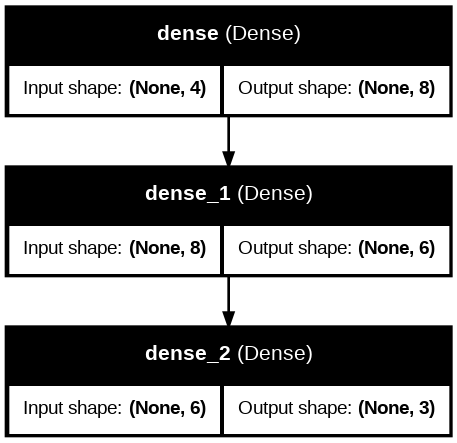

In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.utils import plot_model

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from IPython.display import Image

# Load built-in Iris dataset
data = load_iris()

X = data.data       # 4 input features
y = data.target     # 3 classes: 0, 1, 2

print("Input shape:", X.shape)
print("Target shape:", y.shape)
print("Classes:", data.target_names)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Build neural network model
model = Sequential([
    Input(shape=(4,)),
    Dense(8, activation='relu'),
    Dense(6, activation='relu'),
    Dense(3, activation='softmax')
])

# Compile model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train model
model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=8,
    validation_split=0.2
)

# Model summary
model.summary()

# Evaluate model
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)

# Plot model architecture
plot_model(
    model,
    to_file="iris_multiclass_model.png",
    show_shapes=True,
    show_layer_names=True,
    dpi=96
)

# Display model plot
Image("iris_multiclass_model.png")